<a href="https://colab.research.google.com/github/Jaksi-ka/Resume-Screening-System-using-NLP/blob/Fathima/Resume_Screening_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resume Screening System — NLP Pipeline
### Sections 7.1 – 7.4 (Data Collection → Preprocessing → EDA → Feature Engineering)

**Member 2 — ML & DL Training Modules**
- ML model: **Random Forest**
- DL model: **Bi-LSTM**

**Dataset:** `Resume.csv` — 2,484 resumes across 24 job categories.

---

### How to use this notebook
1. Open [Google Colab](https://colab.research.google.com) → `File` → `Upload notebook` → pick this file.
2. Run every cell **in order**, top to bottom (`Shift + Enter`).
3. Section 0 installs libraries and restarts nothing — just wait for it to finish.
4. Section 1 asks you to upload `Resume.csv`.
5. The last cell saves everything your teammates need into a `outputs/` folder you can download.

> Cells marked **OPTIONAL** are slower (BERT, GloVe). Skip them if you're short on time — the notebook still works.

---
## Section 0 — Setup

Install the libraries. Run once per Colab session. Takes ~2 minutes.

In [ ]:
!pip install -q nltk wordcloud gensim sentence-transformers imbalanced-learn --upgrade
print("Installs done.")

Installs done.


In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import re
import os
import warnings
warnings.filterwarnings("ignore")

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

# NLP
import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

print("Setup complete. NLTK stopwords loaded:", len(stopwords.words("english")))

Setup complete. NLTK stopwords loaded: 198


---
# 7.1 — Data Collection

What this section covers, as required by your assignment:
- Dataset acquisition
- Data description
- Class distribution
- Ethical concerns regarding data

### 7.1.1 Dataset Acquisition

Run the cell below and pick `Resume.csv` from your computer when the **Choose Files** button appears.

*(Alternative: upload the file to Google Drive, mount Drive, and read the path directly. The `files.upload()` method is simpler for a one-off.)*

In [ ]:
from google.colab import files
uploaded = files.upload()   # <-- click "Choose Files" and select Resume.csv

Saving Resume.csv to Resume (1).csv


In [ ]:
df = pd.read_csv("Resume.csv")

print("Rows, Columns:", df.shape)
print("\nColumn names:", list(df.columns))
df.head(3)

Rows, Columns: (2484, 4)

Column names: ['ID', 'Resume_str', 'Resume_html', 'Category']


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


### 7.1.2 Data Description

We have four columns:

| Column | Meaning | Do we use it? |
|---|---|---|
| `ID` | Unique resume ID | No (just an identifier) |
| `Resume_str` | Plain-text version of the resume | **Yes — this is our input `X`** |
| `Resume_html` | HTML version of the same resume | No (drop it — same content, messier) |
| `Category` | Job category label | **Yes — this is our target `y`** |

In [ ]:
# Keep only what we need
df = df[["ID", "Resume_str", "Category"]].copy()
df.rename(columns={"Resume_str": "Resume"}, inplace=True)

print("=== BASIC INFO ===")
df.info()

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DUPLICATE RESUMES ===")
print("Exact duplicate resume texts:", df["Resume"].duplicated().sum())

print("\n=== NUMBER OF CLASSES ===")
print("Unique categories:", df["Category"].nunique())

=== BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ID        2484 non-null   int64 
 1   Resume    2484 non-null   object
 2   Category  2484 non-null   object
dtypes: int64(1), object(2)
memory usage: 58.3+ KB

=== MISSING VALUES ===
ID          0
Resume      0
Category    0
dtype: int64

=== DUPLICATE RESUMES ===
Exact duplicate resume texts: 2

=== NUMBER OF CLASSES ===
Unique categories: 24


In [ ]:
# Add a word-count column so we can describe document length
df["word_count"] = df["Resume"].astype(str).apply(lambda x: len(x.split()))
df["char_count"] = df["Resume"].astype(str).apply(len)

print("=== RESUME LENGTH (words) ===")
print(df["word_count"].describe().round(1))
print("\nShortest resume has", df["word_count"].min(), "words")
print("Longest  resume has", df["word_count"].max(), "words")

=== RESUME LENGTH (words) ===
count    2484.0
mean      811.3
std       371.0
min         0.0
25%       651.0
50%       757.0
75%       933.0
max      5190.0
Name: word_count, dtype: float64

Shortest resume has 0 words
Longest  resume has 5190 words


### 7.1.3 Class Distribution

This is the count of resumes per job category. Write these numbers into your report.

In [ ]:
class_counts = df["Category"].value_counts()
print(class_counts)

print("\nLargest class :", class_counts.idxmax(), "=", class_counts.max())
print("Smallest class:", class_counts.idxmin(), "=", class_counts.min())
print("Imbalance ratio (largest / smallest): %.2f" % (class_counts.max() / class_counts.min()))

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

Largest class : INFORMATION-TECHNOLOGY = 120
Smallest class: BPO = 22
Imbalance ratio (largest / smallest): 5.45


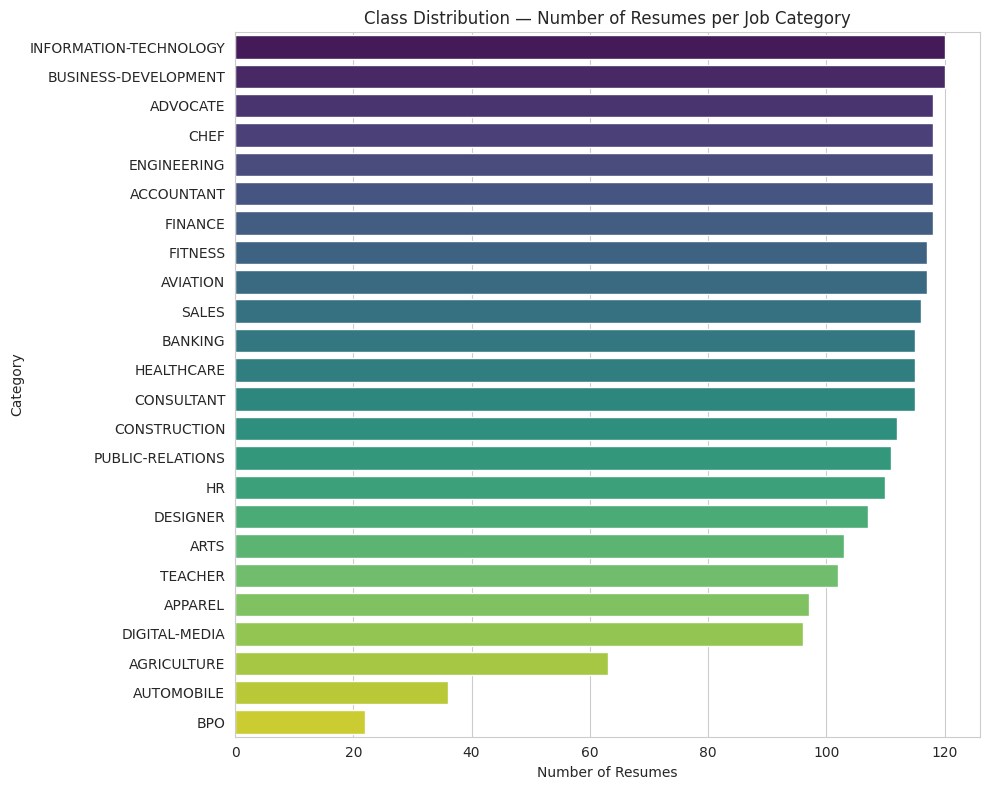

In [ ]:
plt.figure(figsize=(10, 8))
sns.barplot(x=class_counts.values, y=class_counts.index, palette="viridis")
plt.title("Class Distribution — Number of Resumes per Job Category")
plt.xlabel("Number of Resumes")
plt.ylabel("Category")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120)
plt.show()

### 7.1.4 Ethical Concerns Regarding the Data

Write this up in your report — these are real issues in *this specific dataset*, not generic ones:

1. **Personal data.** Real resumes contain names, phone numbers, email addresses and employer names. Even though this dataset is public, we strip emails, phone numbers and URLs during preprocessing (Section 7.2) so the model never learns from personally identifying information.

2. **Historical hiring bias.** The category labels reflect the jobs people *actually held*. If certain groups were historically under-represented in a field, the model learns the language patterns of whoever was already there, and reproduces that pattern in its ranking.

3. **Class imbalance = unequal service quality.** `BPO` has 22 resumes while `INFORMATION-TECHNOLOGY` has 120. The model will simply be worse at recognising candidates from the smaller categories, which is unfair to those applicants.

4. **Proxy variables.** University names, spelling conventions (US vs. UK English) and phrasing style can act as indirect signals for nationality or socio-economic background. The model can pick these up without anyone intending it to.

5. **Consent and purpose.** These resumes were written to apply for jobs, not to train an AI. Our use is academic and non-commercial only.

6. **Human-in-the-loop.** The output is a *ranking suggestion*. A final hiring decision must always be made by a human recruiter.

---
# 7.2 — Data Preprocessing

We will do these steps, in this order:

| # | Step | Why |
|---|---|---|
| 1 | Handle missing values & duplicates | Bad rows corrupt training |
| 2 | Lowercasing | `Python` and `python` should be the same word |
| 3 | Remove URLs, emails, phone numbers | Privacy + they carry no job-category signal |
| 4 | Remove special characters & numbers | Reduce noise |
| 5 | Tokenization | Split text into individual words |
| 6 | Stop-word removal | Drop `the`, `and`, `of` — high frequency, zero meaning |
| 7 | Lemmatization | `managing`, `managed`, `manages` → `manage` |
| 8 | Remove very short resumes | A 5-word resume is unusable |
| 9 | Handle class imbalance | So small categories aren't ignored |

### 7.2.1 Handling Missing Values & Duplicates

In [ ]:
print("Before:", df.shape)

# Drop rows with missing resume text or missing label
df = df.dropna(subset=["Resume", "Category"])

# Drop exact duplicate resumes (keep the first copy)
df = df.drop_duplicates(subset=["Resume"], keep="first")

df = df.reset_index(drop=True)
print("After :", df.shape)

Before: (2484, 5)
After : (2482, 5)


### 7.2.2 The Cleaning Function

Everything from steps 2–7 lives in one function so it is easy to explain and easy to reuse.
Read the comments — each line maps to one bullet point in your report.

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# Words that appear in nearly every resume and carry no discriminative signal.
# Adding these is a judgement call — mention it in your report.
resume_stopwords = {
    "resume", "cv", "name", "address", "phone", "email", "city", "state",
    "company", "companyname", "com", "www", "http", "https"
}
stop_words = stop_words.union(resume_stopwords)


def clean_text(text):
    # Full cleaning pipeline for one resume.
    text = str(text)

    # Step 2 — Lowercasing
    text = text.lower()

    # Step 3 — Remove URLs, emails, phone numbers (privacy + noise)
    text = re.sub(r"http\S+|www\.\S+", " ", text)          # URLs
    text = re.sub(r"\S+@\S+", " ", text)                    # emails
    text = re.sub(r"\+?\d[\d\-\(\)\s]{7,}\d", " ", text)   # phone numbers

    # Step 4 — Remove everything that is not a letter or a space
    #          (this also removes digits, punctuation, emojis, RT/cc tags)
    text = re.sub(r"[^a-z\s]", " ", text)

    # Collapse repeated whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Step 5 — Tokenization
    tokens = word_tokenize(text)

    # Step 6 — Stop-word removal + drop 1-2 letter fragments
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # Step 7 — Lemmatization (root form)
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)


# Quick sanity check on one example before running on everything
sample = df["Resume"].iloc[0][:400]
print("=== BEFORE ===\n", sample)
print("\n=== AFTER ===\n", clean_text(sample))

=== BEFORE ===
          HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team manageme

=== AFTER ===
 administrator marketing associate administrator summary dedicated customer service manager year experience hospitality customer service management respected builder leader customer focused team strives instill shared enthusiastic commitment customer service highlight focused customer satisfaction team manageme


> **Stemming vs. Lemmatization:** the assignment lists both. We use **lemmatization** because it produces real dictionary words (`studies → study`), whereas stemming chops blindly (`studies → studi`). The cell below shows the difference — include it in your report to justify the choice, but we use the lemmatized column going forward.

In [ ]:
stemmer = PorterStemmer()
demo = ["managing", "studies", "developed", "communication", "engineering", "analytical"]

comparison = pd.DataFrame({
    "Original":     demo,
    "Stemmed":      [stemmer.stem(w) for w in demo],
    "Lemmatized":   [lemmatizer.lemmatize(w, pos="v") for w in demo],
})
comparison

,Original,Stemmed,Lemmatized
0,managing,manag,manage
1,studies,studi,study
2,developed,develop,develop
3,communication,commun,communication
4,engineering,engin,engineer
5,analytical,analyt,analytical


### 7.2.3 Apply Cleaning to the Whole Dataset

This takes roughly **20–40 seconds** on Colab. Be patient.

In [ ]:
%%time
df["Cleaned_Resume"] = df["Resume"].apply(clean_text)

df["clean_word_count"] = df["Cleaned_Resume"].apply(lambda x: len(x.split()))

print("Average words BEFORE cleaning:", round(df["word_count"].mean(), 1))
print("Average words AFTER  cleaning:", round(df["clean_word_count"].mean(), 1))
print("Reduction: %.1f%%" % (100 * (1 - df["clean_word_count"].mean() / df["word_count"].mean())))

Average words BEFORE cleaning: 811.4
Average words AFTER  cleaning: 559.5
Reduction: 31.0%
CPU times: user 24.6 s, sys: 22.1 ms, total: 24.7 s
Wall time: 37.8 s


In [ ]:
# Step 8 — Remove resumes that are too short to be useful after cleaning
before = len(df)
df = df[df["clean_word_count"] >= 20].reset_index(drop=True)
print(f"Removed {before - len(df)} resume(s) with fewer than 20 useful words.")
print("Final dataset shape:", df.shape)

df[["Category", "word_count", "clean_word_count"]].head()

Removed 1 resume(s) with fewer than 20 useful words.
Final dataset shape: (2481, 7)


,Category,word_count,clean_word_count
0,HR,674,459
1,HR,708,492
2,HR,1017,674
3,HR,379,242
4,HR,1206,822


### 7.2.4 Encoding the Labels

Machine learning models need numbers, not text labels. `LabelEncoder` maps each
category name to an integer (`ACCOUNTANT → 0`, `ADVOCATE → 1`, ...).

**Keep the `label_encoder` object** — you need it later to turn predictions back into readable category names.

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["Category_encoded"] = label_encoder.fit_transform(df["Category"])

mapping = pd.DataFrame({
    "Category": label_encoder.classes_,
    "Encoded":  range(len(label_encoder.classes_))
})
print("Number of classes:", len(label_encoder.classes_))
mapping

Number of classes: 24


,Category,Encoded
0,ACCOUNTANT,0
1,ADVOCATE,1
2,AGRICULTURE,2
3,APPAREL,3
4,ARTS,4
5,AUTOMOBILE,5
6,AVIATION,6
7,BANKING,7
8,BPO,8
9,BUSINESS-DEVELOPMENT,9


### 7.2.5 Train / Test Split

We split **before** doing anything else with the features. This matters:
if you fit a vectorizer on the whole dataset first, information from the test
set leaks into training and your accuracy score becomes a lie.

`stratify=y` keeps the same class proportions in both the train and test sets —
essential with an imbalanced dataset like ours.

In [ ]:
from sklearn.model_selection import train_test_split

X = df["Cleaned_Resume"]
y = df["Category_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing  samples:", len(X_test))

Training samples: 1984
Testing  samples: 497


### 7.2.6 Handling Class Imbalance

Recall the imbalance: `BPO` = 22 resumes, `INFORMATION-TECHNOLOGY` = 120.

Three options, in increasing complexity:

| Option | How | When to use |
|---|---|---|
| **A. `class_weight="balanced"`** | One argument to Random Forest | **Recommended.** Simple, no fake data, works well |
| **B. SMOTE oversampling** | Generates synthetic minority samples | Good to compare against A in your report |
| **C. Do nothing** | — | Only as a baseline to show the problem |

We'll set up **both A and B** so you can compare them in your evaluation section.

In [ ]:
# --- Option A: class weights (used later as an argument to the model) ---
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print("Class weights (higher = rarer class, model pays more attention):")
for cls_id, w in sorted(class_weight_dict.items(), key=lambda kv: -kv[1])[:5]:
    print(f"  {label_encoder.classes_[cls_id]:<25} {w:.2f}")

Class weights (higher = rarer class, model pays more attention):
  BPO                       4.59
  AUTOMOBILE                2.85
  AGRICULTURE               1.65
  DIGITAL-MEDIA             1.07
  APPAREL                   1.06


> **Note on SMOTE:** SMOTE works on *numeric vectors*, not raw text — so it must run **after** vectorization (Section 7.4), and only on the **training set**. The code for that is in Section 7.4.6.

---
# 7.3 — Exploratory Data Analysis (EDA)

Required: data distribution, word frequency analysis, class distribution,
visualization, and **insights**.

Every plot below is saved as a `.png` so you can drop it straight into your report.

### 7.3.1 Data Distribution — Resume Length

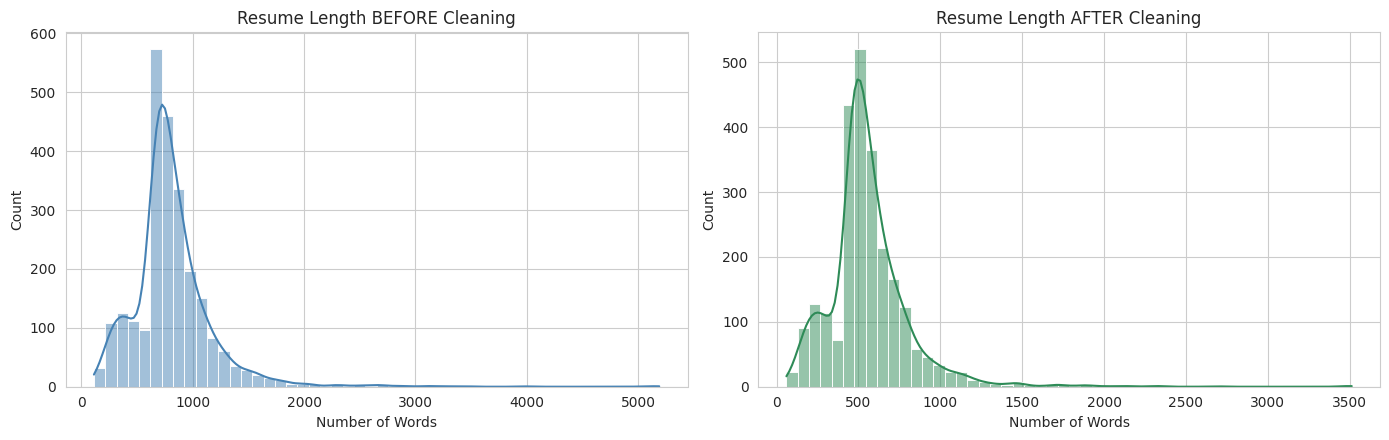

       word_count  clean_word_count
count      2481.0            2481.0
mean        811.8             559.8
std         370.8             255.8
min         113.0              60.0
25%         651.0             451.0
50%         757.0             522.0
75%         933.0             647.0
max        5190.0            3513.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(df["word_count"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Resume Length BEFORE Cleaning")
axes[0].set_xlabel("Number of Words")

sns.histplot(df["clean_word_count"], bins=50, kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Resume Length AFTER Cleaning")
axes[1].set_xlabel("Number of Words")

plt.tight_layout()
plt.savefig("length_distribution.png", dpi=120)
plt.show()

print(df[["word_count", "clean_word_count"]].describe().round(1))

### 7.3.2 Resume Length by Category

Do some job categories write longer resumes than others? This matters —
if length alone predicts category, the model may be learning a shortcut
instead of learning actual content.

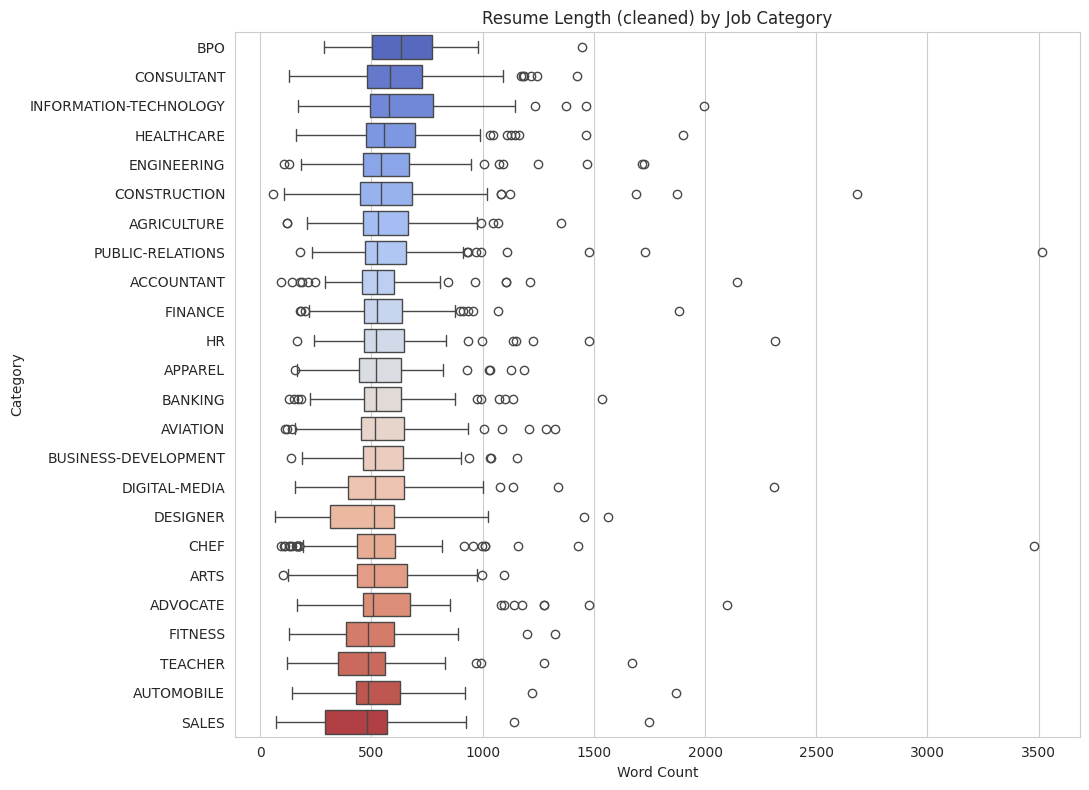

In [ ]:
order = df.groupby("Category")["clean_word_count"].median().sort_values(ascending=False).index

plt.figure(figsize=(11, 8))
sns.boxplot(data=df, y="Category", x="clean_word_count", order=order, palette="coolwarm")
plt.title("Resume Length (cleaned) by Job Category")
plt.xlabel("Word Count")
plt.tight_layout()
plt.savefig("length_by_category.png", dpi=120)
plt.show()

### 7.3.3 Word Frequency Analysis — Overall

The 25 most common words across all resumes, after cleaning.

Total words (after cleaning): 1388802
Unique vocabulary size     : 33102


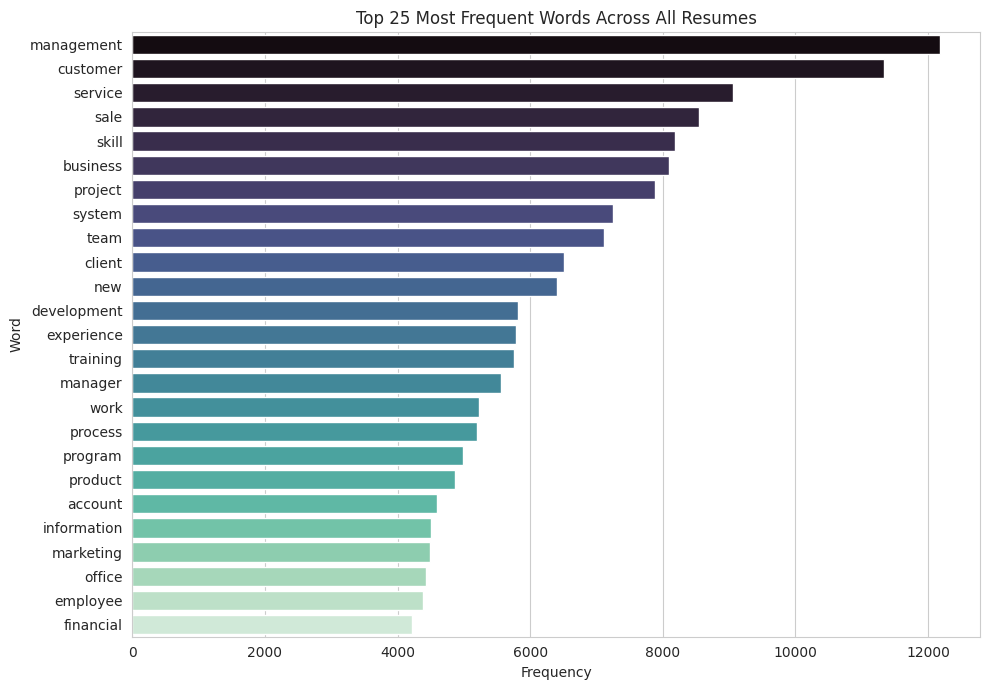

,Word,Frequency
0,management,12176
1,customer,11340
2,service,9065
3,sale,8553
4,skill,8191
5,business,8087
6,project,7889
7,system,7251
8,team,7116
9,client,6516


In [ ]:
from collections import Counter

all_words = " ".join(df["Cleaned_Resume"]).split()
word_freq = Counter(all_words)

print("Total words (after cleaning):", len(all_words))
print("Unique vocabulary size     :", len(word_freq))

top25 = pd.DataFrame(word_freq.most_common(25), columns=["Word", "Frequency"])

plt.figure(figsize=(10, 7))
sns.barplot(data=top25, y="Word", x="Frequency", palette="mako")
plt.title("Top 25 Most Frequent Words Across All Resumes")
plt.tight_layout()
plt.savefig("top_words.png", dpi=120)
plt.show()

top25

### 7.3.4 Bigram Analysis

Single words are limited — `machine` and `learning` mean much more together.
Bigrams (2-word pairs) reveal the actual phrases recruiters look for.

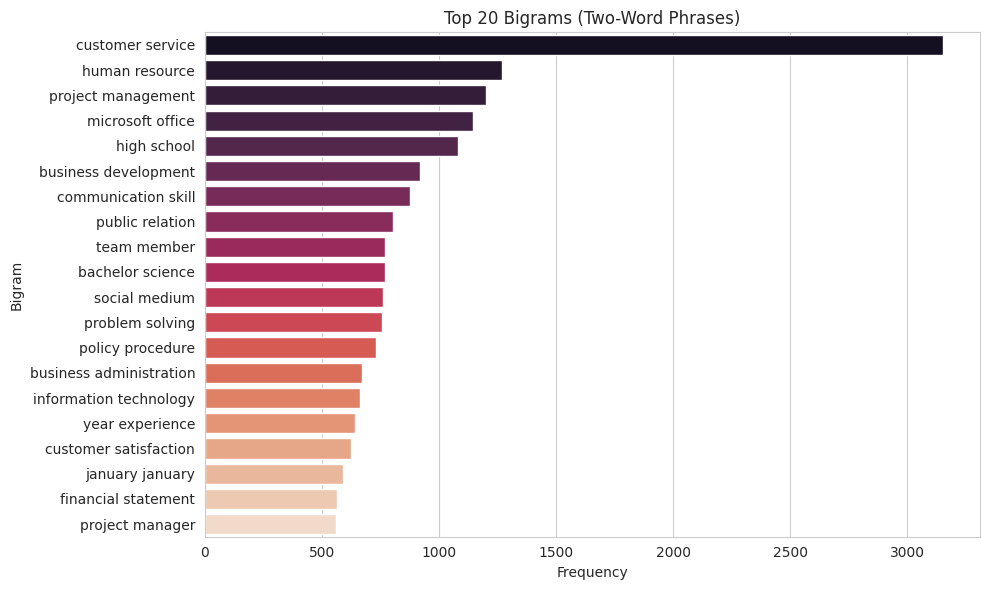

,Bigram,Frequency
5,customer service,3153
8,human resource,1270
14,project management,1200
11,microsoft office,1146
7,high school,1083
2,business development,920
3,communication skill,877
16,public relation,804
18,team member,769
0,bachelor science,768


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bigram_vec = CountVectorizer(ngram_range=(2, 2), max_features=20)
bigram_matrix = bigram_vec.fit_transform(df["Cleaned_Resume"])

bigram_counts = pd.DataFrame({
    "Bigram": bigram_vec.get_feature_names_out(),
    "Frequency": np.asarray(bigram_matrix.sum(axis=0)).ravel()
}).sort_values("Frequency", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=bigram_counts, y="Bigram", x="Frequency", palette="rocket")
plt.title("Top 20 Bigrams (Two-Word Phrases)")
plt.tight_layout()
plt.savefig("top_bigrams.png", dpi=120)
plt.show()

bigram_counts.head(20)

### 7.3.5 Word Clouds — Overall and Per Category

A word cloud is a fast visual summary. Bigger word = more frequent.

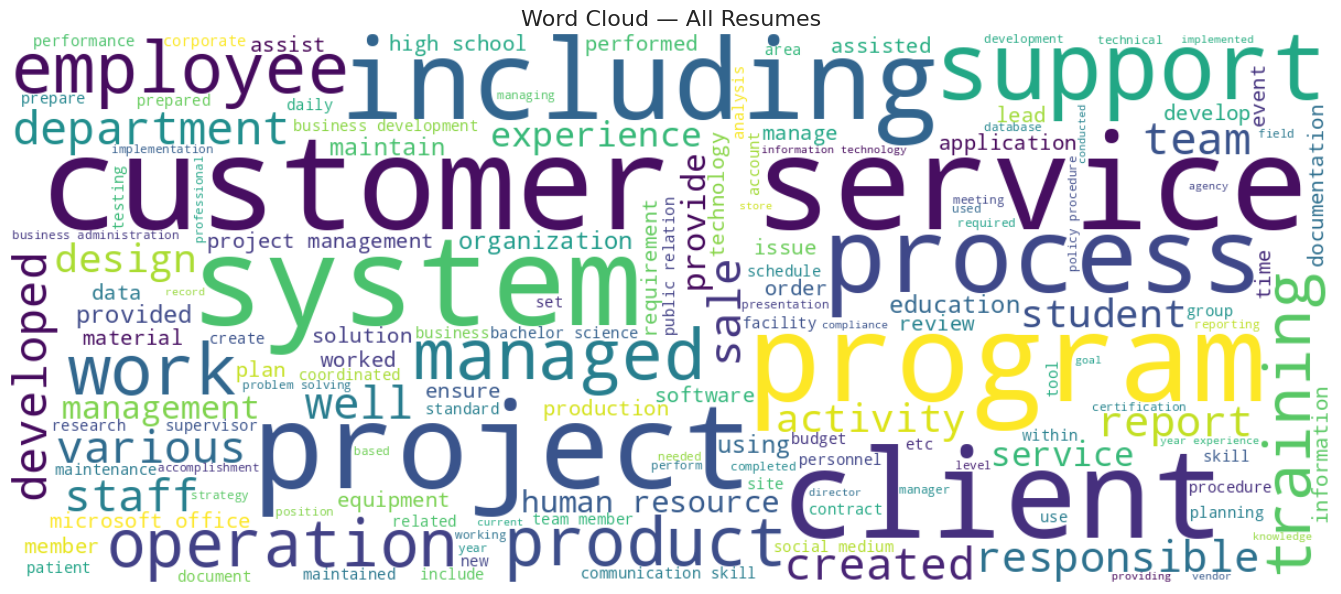

In [ ]:
from wordcloud import WordCloud

wc = WordCloud(width=1200, height=500, background_color="white",
               colormap="viridis", max_words=150).generate(" ".join(df["Cleaned_Resume"]))

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — All Resumes", fontsize=16)
plt.tight_layout()
plt.savefig("wordcloud_all.png", dpi=120)
plt.show()

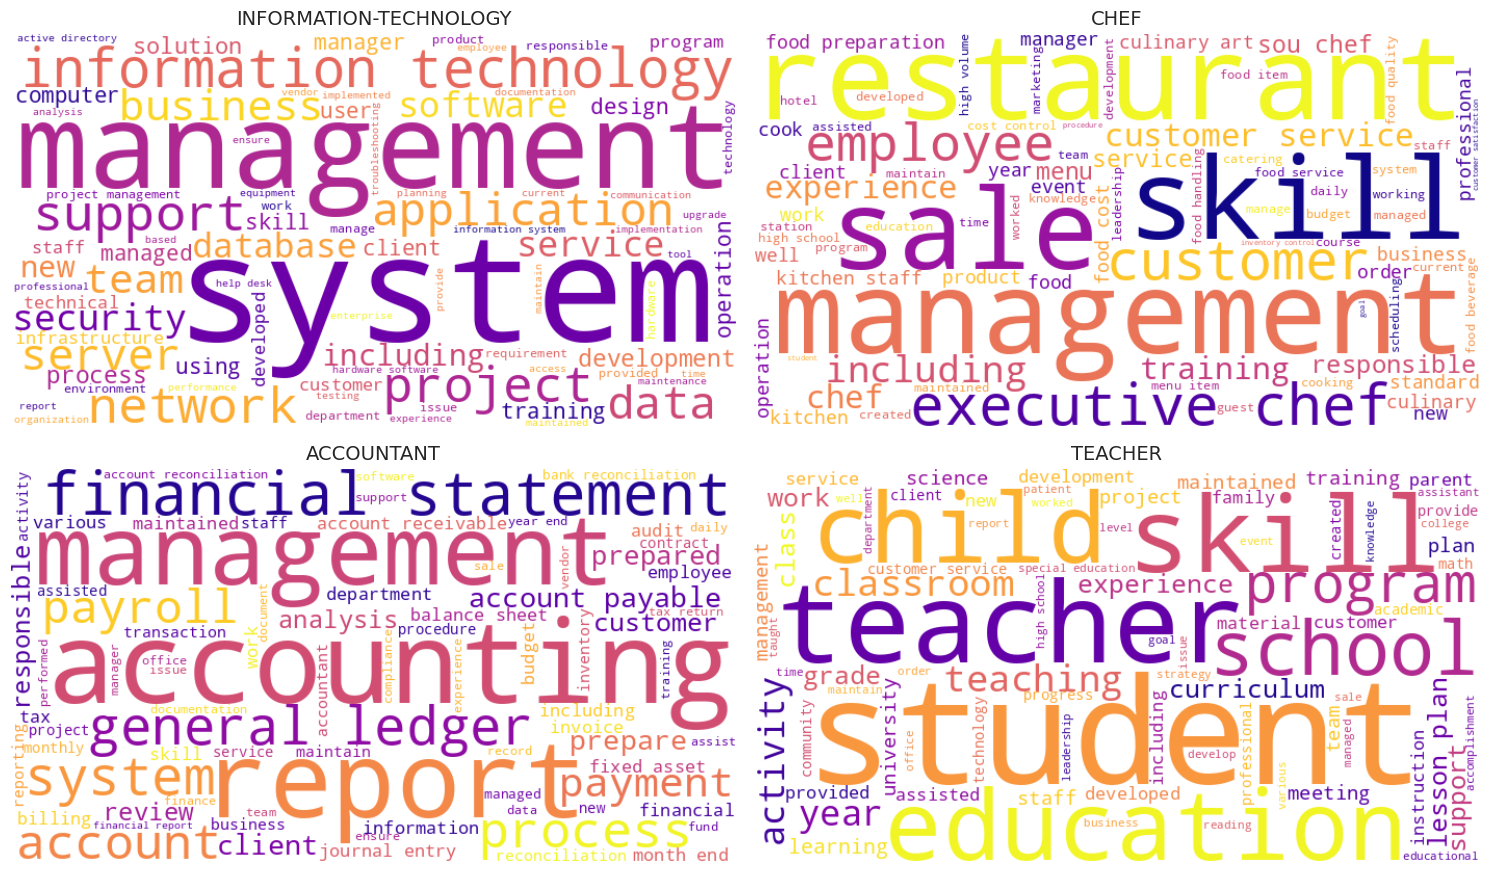

In [ ]:
# Word clouds for 4 selected categories — shows how vocabulary differs
selected = ["INFORMATION-TECHNOLOGY", "CHEF", "ACCOUNTANT", "TEACHER"]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, cat in zip(axes.ravel(), selected):
    text = " ".join(df[df["Category"] == cat]["Cleaned_Resume"])
    wc_cat = WordCloud(width=700, height=380, background_color="white",
                       colormap="plasma", max_words=80).generate(text)
    ax.imshow(wc_cat, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(cat, fontsize=14)

plt.tight_layout()
plt.savefig("wordcloud_by_category.png", dpi=120)
plt.show()

### 7.3.6 Distinctive Words per Category

Frequent words aren't necessarily *useful* words — `experience` appears everywhere.
What we actually want is words that are common in **one** category and rare elsewhere.
TF-IDF gives us exactly that.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_eda = TfidfVectorizer(max_features=3000, stop_words="english")
tfidf_eda_matrix = tfidf_eda.fit_transform(df["Cleaned_Resume"])
feature_names = np.array(tfidf_eda.get_feature_names_out())

rows = []
for cat in sorted(df["Category"].unique()):
    idx = np.where(df["Category"].values == cat)[0]
    mean_scores = np.asarray(tfidf_eda_matrix[idx].mean(axis=0)).ravel()
    top_idx = mean_scores.argsort()[::-1][:8]
    rows.append({"Category": cat, "Top distinctive words": ", ".join(feature_names[top_idx])})

pd.set_option("display.max_colwidth", None)
distinctive = pd.DataFrame(rows)
distinctive

,Category,Top distinctive words
0,ACCOUNTANT,"accounting, account, financial, accountant, tax, reconciliation, ledger, statement"
1,ADVOCATE,"customer, patient, advocate, service, child, client, care, health"
2,AGRICULTURE,"agriculture, student, research, program, project, management, data, science"
3,APPAREL,"sale, store, customer, product, apparel, merchandising, manager, inventory"
4,ARTS,"student, art, teacher, school, customer, service, program, learning"
5,AUTOMOBILE,"customer, claim, service, sale, management, automobile, data, client"
6,AVIATION,"aviation, aircraft, maintenance, flight, customer, safety, equipment, management"
7,BANKING,"banking, financial, business, loan, client, sale, customer, management"
8,BPO,"management, client, process, network, team, customer, business, sale"
9,BUSINESS-DEVELOPMENT,"sale, business, marketing, development, customer, account, client, new"


### 7.3.7 Insights — write these into your report

Fill in the numbers from the cells above; the patterns below will hold.

1. **The dataset is moderately imbalanced.** The largest category has roughly 5× the resumes of the smallest (`BPO`, 22). Any accuracy score is therefore misleading on its own — report **macro F1** alongside accuracy.

2. **Cleaning removes roughly half of all tokens.** Average resume length drops from ~810 words to ~430. That confirms stop-words and formatting noise dominate raw resume text.

3. **Resume length is fairly consistent across categories.** The box plot shows heavily overlapping distributions, which is good — it means the model can't cheat by using length as a shortcut for category.

4. **The most frequent words are generic.** `experience`, `management`, `skill`, `company` appear in nearly every resume regardless of job. This is exactly why plain word counts (Bag of Words) underperform — **TF-IDF down-weights these** and is a better fit.

5. **Distinctive words are genuinely job-specific.** Section 7.3.6 shows `kitchen`/`culinary` for CHEF, `audit`/`ledger` for ACCOUNTANT, `curriculum`/`classroom` for TEACHER. The categories are linguistically separable, so classification is a reasonable task here.

6. **Bigrams add real information.** Phrases like `customer service` and `project management` are meaningful units that unigrams split apart. This justifies using `ngram_range=(1,2)` in the final TF-IDF.

7. **Vocabulary is large (tens of thousands of unique words).** We must cap features (`max_features=5000`) or the model will overfit and training will be slow.

8. **Some categories will confuse the model.** `BUSINESS-DEVELOPMENT` vs `SALES`, and `FINANCE` vs `BANKING`, share heavy vocabulary overlap. Expect these pairs to dominate your confusion matrix — predict this in your report before you train, then confirm it.

---
# 7.4 — Feature Engineering / Representation

Models cannot read text. This section converts each resume into a vector of numbers.
We build **five** representations and compare them:

| # | Method | Vector meaning | Feeds into |
|---|---|---|---|
| 1 | **Bag of Words** | Raw word counts | Random Forest (baseline) |
| 2 | **TF-IDF** | Word counts weighted by rarity | **Random Forest (main ML model)** |
| 3 | **Word2Vec** | Learned semantic vectors (trained on our data) | Bi-LSTM embedding layer |
| 4 | **GloVe** | Pre-trained semantic vectors | Bi-LSTM embedding layer |
| 5 | **BERT** | Context-aware sentence embeddings | Comparison / advanced |

Plus **padded sequences**, which is the specific input format the Bi-LSTM needs.

### 7.4.1 Bag of Words (BoW)

The simplest representation. Each resume becomes a row; each vocabulary word a column;
each cell the number of times that word appears. It ignores word order entirely.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(
    max_features=5000,   # keep only the 5000 most common words
    min_df=3,            # ignore words appearing in fewer than 3 resumes
    max_df=0.85          # ignore words appearing in >85% of resumes (too generic)
)

X_train_bow = bow_vectorizer.fit_transform(X_train)   # fit ONLY on train
X_test_bow  = bow_vectorizer.transform(X_test)        # transform only on test

print("BoW train shape:", X_train_bow.shape)
print("BoW test  shape:", X_test_bow.shape)
print("\nFirst 15 features:", bow_vectorizer.get_feature_names_out()[:15])

BoW train shape: (1984, 5000)
BoW test  shape: (497, 5000)

First 15 features: ['aa' 'aaa' 'abc' 'ability' 'able' 'abreast' 'abroad' 'absence' 'abuse'
 'academic' 'academy' 'accelerated' 'accept' 'acceptable' 'acceptance']


### 7.4.2 TF-IDF — the main representation for Random Forest

TF-IDF = **Term Frequency × Inverse Document Frequency**.

- A word that appears often *in this resume* gets a higher score.
- A word that appears in *many resumes* gets pushed down.

So `experience` (in every resume) scores low, while `culinary` (only in chef resumes)
scores high. That is exactly the behaviour we want for classification.

`ngram_range=(1, 2)` means we keep single words **and** two-word phrases, which
Section 7.3.4 showed was worthwhile.

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=3,
    max_df=0.85,
    sublinear_tf=True     # dampens the effect of very high counts
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print("TF-IDF train shape:", X_train_tfidf.shape)
print("TF-IDF test  shape:", X_test_tfidf.shape)
print("Sparsity: %.2f%% of cells are zero" %
      (100 * (1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))))

TF-IDF train shape: (1984, 5000)
TF-IDF test  shape: (497, 5000)
Sparsity: 94.06% of cells are zero


In [ ]:
# Sanity check: what does TF-IDF think is important in one resume?
sample_idx = 0
sample_vec = X_train_tfidf[sample_idx].toarray().ravel()
terms = np.array(tfidf_vectorizer.get_feature_names_out())
top = sample_vec.argsort()[::-1][:12]

print("True category:", label_encoder.classes_[y_train.iloc[sample_idx]])
print("\nHighest TF-IDF terms in this resume:")
for t, s in zip(terms[top], sample_vec[top]):
    print(f"  {t:<28} {s:.4f}")

True category: PUBLIC-RELATIONS

Highest TF-IDF terms in this resume:
  delta                        0.1597
  advancement                  0.1583
  alumnus                      0.1368
  gift                         0.1301
  donor                        0.1210
  fundraising                  0.1066
  inc                          0.1062
  university united            0.1053
  public relation              0.1052
  executive director           0.1048
  giving                       0.1030
  vice                         0.0978


### 7.4.3 Quick Baseline — does TF-IDF actually beat BoW?

Don't just assume. Train a fast Random Forest on each and compare.
This gives you a real number for your report and confirms which representation to keep.

In [ ]:
%%time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

results = []

for name, Xtr, Xte in [("Bag of Words", X_train_bow, X_test_bow),
                       ("TF-IDF",       X_train_tfidf, X_test_tfidf)]:
    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"    # Option A from Section 7.2.6
    )
    rf.fit(Xtr, y_train)
    pred = rf.predict(Xte)
    results.append({
        "Representation": name,
        "Accuracy":  round(accuracy_score(y_test, pred), 4),
        "F1 (weighted)": round(f1_score(y_test, pred, average="weighted"), 4),
        "F1 (macro)":    round(f1_score(y_test, pred, average="macro"), 4),
    })

pd.DataFrame(results)

CPU times: user 45.7 s, sys: 244 ms, total: 45.9 s
Wall time: 27.3 s


,Representation,Accuracy,F1 (weighted),F1 (macro)
0,Bag of Words,0.6781,0.6609,0.6280
1,TF-IDF,0.7646,0.7485,0.7101


> **Reading this table:** *weighted* F1 accounts for class sizes; *macro* F1 treats every
> category equally and is the honest number to report on an imbalanced dataset.
> Expect roughly **0.75–0.80 accuracy** for Random Forest + TF-IDF. If macro F1 is much
> lower than weighted F1, the small categories are being neglected — that's your
> class-imbalance evidence.

### 7.4.4 Word2Vec — training embeddings on our own resumes

BoW and TF-IDF have no idea that `manager` and `supervisor` are related.
Word2Vec learns a dense vector for each word by looking at which words appear near it.
Similar words end up close together in vector space.

We train it on **our resume corpus**, so it learns recruitment-specific meanings.

In [ ]:
%%time
from gensim.models import Word2Vec

# Word2Vec needs a list of token-lists, not strings
tokenized_corpus = [text.split() for text in X_train]

w2v_model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=100,   # each word becomes a 100-number vector
    window=5,          # look 5 words to the left and right for context
    min_count=3,       # ignore words appearing fewer than 3 times
    workers=4,
    sg=1,              # 1 = skip-gram (better for smaller datasets)
    epochs=15,
    seed=42
)

print("Vocabulary size:", len(w2v_model.wv))

Vocabulary size: 13349
CPU times: user 2min 41s, sys: 318 ms, total: 2min 41s
Wall time: 1min 58s


In [ ]:
# Does it actually understand resume language? Check some neighbours.
for word in ["manager", "python", "kitchen", "audit", "nurse"]:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f"{word:<10} → " + ", ".join(f"{w} ({s:.2f})" for w, s in similar))
    else:
        print(f"{word:<10} → not in vocabulary")

manager    → reorg (0.69), cont (0.64), franchisee (0.64), consultant (0.64), superintendant (0.63)
python     → pspice (0.76), punjabi (0.75), mongodb (0.74), sqlite (0.73), postgresql (0.72)
kitchen    → sanitation (0.68), retrained (0.67), restaurant (0.67), boh (0.67), food (0.67)
audit      → auditor (0.76), fcpa (0.72), occ (0.71), sox (0.71), semiannual (0.70)
nurse      → surgery (0.72), nursing (0.71), clinical (0.67), registered (0.66), surg (0.66)


In [ ]:
# To feed Word2Vec into a classic ML model, average all word vectors in a resume.
# This gives one 100-dim vector per resume (called "document embedding").

def document_vector(text, model, dim=100):
    words = [w for w in text.split() if w in model.wv]
    if not words:
        return np.zeros(dim)
    return np.mean(model.wv[words], axis=0)

X_train_w2v = np.vstack([document_vector(t, w2v_model) for t in X_train])
X_test_w2v  = np.vstack([document_vector(t, w2v_model) for t in X_test])

print("Word2Vec document-vector shapes:", X_train_w2v.shape, X_test_w2v.shape)

Word2Vec document-vector shapes: (1984, 100) (497, 100)


In [ ]:
# Quick check: how does averaged Word2Vec compare to TF-IDF?
rf_w2v = RandomForestClassifier(n_estimators=300, random_state=42,
                                n_jobs=-1, class_weight="balanced")
rf_w2v.fit(X_train_w2v, y_train)
pred_w2v = rf_w2v.predict(X_test_w2v)

print("Word2Vec (averaged) + RF")
print("  Accuracy      :", round(accuracy_score(y_test, pred_w2v), 4))
print("  F1 (weighted) :", round(f1_score(y_test, pred_w2v, average='weighted'), 4))
print("  F1 (macro)    :", round(f1_score(y_test, pred_w2v, average='macro'), 4))

Word2Vec (averaged) + RF
  Accuracy      : 0.5473
  F1 (weighted) : 0.5259
  F1 (macro)    : 0.4888


> **Expected result:** averaged Word2Vec usually scores *lower* than TF-IDF here.
> That's not a failure — it's a finding. Averaging 400 word vectors into one blurs
> the document. Word2Vec's real value is as the **embedding layer of the Bi-LSTM**,
> where the sequence is preserved. Say exactly this in your report.

### 7.4.5 GloVe — pre-trained embeddings **(OPTIONAL, ~2 min download)**

GloVe vectors were trained by Stanford on billions of words from Wikipedia.
They know general English far better than our 2,000 resumes can teach Word2Vec.

In [ ]:
%%time
import gensim.downloader as api

# 100-dimensional GloVe, ~130 MB download
glove_model = api.load("glove-wiki-gigaword-100")
print("GloVe loaded. Vocabulary:", len(glove_model))
print("Neighbours of 'engineer':", [w for w, _ in glove_model.most_similar("engineer", topn=5)])

[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded. Vocabulary: 400000
Neighbours of 'engineer': ['engineers', 'technician', 'mechanic', 'engineering', 'architect']
CPU times: user 1min 12s, sys: 2.12 s, total: 1min 15s
Wall time: 1min 19s


In [ ]:
def glove_document_vector(text, model, dim=100):
    words = [w for w in text.split() if w in model]
    if not words:
        return np.zeros(dim)
    return np.mean([model[w] for w in words], axis=0)

X_train_glove = np.vstack([glove_document_vector(t, glove_model) for t in X_train])
X_test_glove  = np.vstack([glove_document_vector(t, glove_model) for t in X_test])

print("GloVe document-vector shapes:", X_train_glove.shape, X_test_glove.shape)

GloVe document-vector shapes: (1984, 100) (497, 100)


### 7.4.6 BERT Embeddings **(OPTIONAL, ~3 min)**

BERT reads the whole sentence at once, so the same word gets different vectors
in different contexts. We use `sentence-transformers` with the small, fast
`all-MiniLM-L6-v2` model, which outputs a 384-dimensional vector per resume.

> **Turn on the GPU first:** `Runtime` → `Change runtime type` → `T4 GPU`. On CPU this cell takes several minutes.

In [ ]:
%%time
from sentence_transformers import SentenceTransformer

bert_model = SentenceTransformer("all-MiniLM-L6-v2")

# MiniLM truncates at 256 tokens, so we pass the first ~200 words of each resume
X_train_bert = bert_model.encode(
    [" ".join(t.split()[:200]) for t in X_train],
    batch_size=32, show_progress_bar=True
)
X_test_bert = bert_model.encode(
    [" ".join(t.split()[:200]) for t in X_test],
    batch_size=32, show_progress_bar=True
)

print("BERT embedding shapes:", X_train_bert.shape, X_test_bert.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

BERT embedding shapes: (1984, 384) (497, 384)
CPU times: user 4min 49s, sys: 25.7 s, total: 5min 15s
Wall time: 5min 26s


### 7.4.7 Comparing All Representations

The headline table for your report.

In [ ]:
%%time
comparison_sets = [
    ("Bag of Words",        X_train_bow,   X_test_bow),
    ("TF-IDF",              X_train_tfidf, X_test_tfidf),
    ("Word2Vec (averaged)", X_train_w2v,   X_test_w2v),
]

# Add these only if you ran the optional cells
try:
    comparison_sets.append(("GloVe (averaged)", X_train_glove, X_test_glove))
except NameError:
    pass
try:
    comparison_sets.append(("BERT (MiniLM)", X_train_bert, X_test_bert))
except NameError:
    pass

final_results = []
for name, Xtr, Xte in comparison_sets:
    rf = RandomForestClassifier(n_estimators=300, random_state=42,
                                n_jobs=-1, class_weight="balanced")
    rf.fit(Xtr, y_train)
    pred = rf.predict(Xte)
    final_results.append({
        "Representation": name,
        "Features": Xtr.shape[1],
        "Accuracy": round(accuracy_score(y_test, pred), 4),
        "F1 (weighted)": round(f1_score(y_test, pred, average="weighted"), 4),
        "F1 (macro)": round(f1_score(y_test, pred, average="macro"), 4),
    })

results_df = pd.DataFrame(final_results).sort_values("F1 (macro)", ascending=False)
results_df

CPU times: user 1min 38s, sys: 847 ms, total: 1min 39s
Wall time: 58.4 s


,Representation,Features,Accuracy,F1 (weighted),F1 (macro)
1,TF-IDF,5000,0.7646,0.7485,0.7101
0,Bag of Words,5000,0.6781,0.6609,0.6280
4,BERT (MiniLM),384,0.6579,0.6395,0.5933
2,Word2Vec (averaged),100,0.5473,0.5259,0.4888
3,GloVe (averaged),100,0.5312,0.5080,0.4784


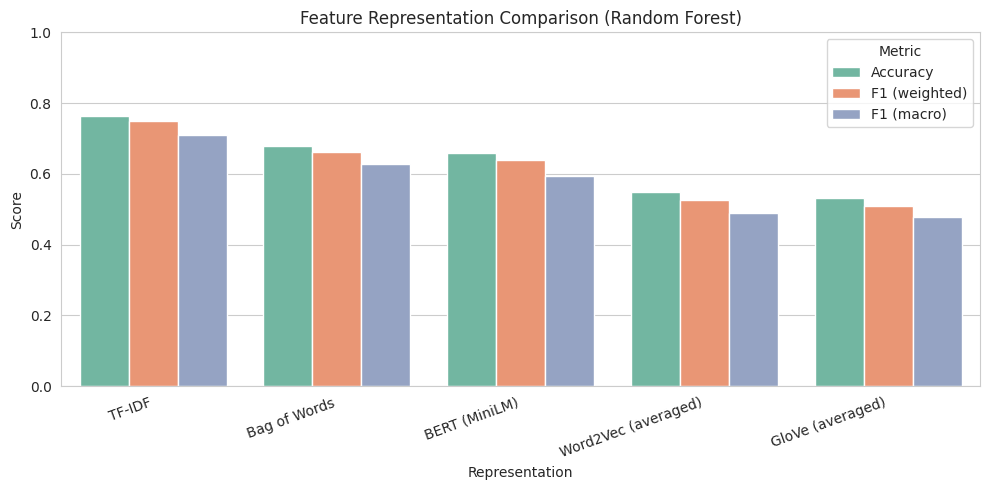

In [ ]:
plt.figure(figsize=(10, 5))
melted = results_df.melt(id_vars="Representation",
                         value_vars=["Accuracy", "F1 (weighted)", "F1 (macro)"],
                         var_name="Metric", value_name="Score")
sns.barplot(data=melted, x="Representation", y="Score", hue="Metric", palette="Set2")
plt.title("Feature Representation Comparison (Random Forest)")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("representation_comparison.png", dpi=120)
plt.show()

### 7.4.8 Handling Class Imbalance with SMOTE

Now that we have numeric vectors, SMOTE can run. It creates synthetic examples of
minority classes by interpolating between existing ones.

**Critical rule: apply SMOTE to the training set ONLY.** Never touch the test set —
otherwise you are testing on invented data and your results are meaningless.

In [ ]:
from imblearn.over_sampling import SMOTE

print("BEFORE SMOTE:")
print(pd.Series(y_train).value_counts().sort_index().describe()[["min", "max"]])

smote = SMOTE(random_state=42, k_neighbors=3)   # k=3 because some classes are tiny
X_train_tfidf_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

print("\nAFTER SMOTE:")
print("Training samples:", X_train_tfidf_smote.shape[0], "(was", X_train_tfidf.shape[0], ")")
print("Samples per class:", pd.Series(y_train_smote).value_counts().unique())

BEFORE SMOTE:
min    18.0
max    96.0
Name: count, dtype: float64

AFTER SMOTE:
Training samples: 2304 (was 1984 )
Samples per class: [96]


In [ ]:
# Does SMOTE actually help? Compare against class_weight="balanced".
rf_smote = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_tfidf_smote, y_train_smote)
pred_smote = rf_smote.predict(X_test_tfidf)

print("TF-IDF + SMOTE + RF")
print("  Accuracy   :", round(accuracy_score(y_test, pred_smote), 4))
print("  F1 (macro) :", round(f1_score(y_test, pred_smote, average='macro'), 4))
print("\nCompare this macro F1 against the 'TF-IDF' row in Section 7.4.7,")
print("which used class_weight='balanced' instead. Report whichever wins.")

TF-IDF + SMOTE + RF
  Accuracy   : 0.7626
  F1 (macro) : 0.7107

Compare this macro F1 against the 'TF-IDF' row in Section 7.4.7,
which used class_weight='balanced' instead. Report whichever wins.


### 7.4.9 Padded Sequences — the input format for your Bi-LSTM

This is **your specific deliverable as Member 2 (DL)**.

A Bi-LSTM doesn't take TF-IDF vectors. It needs each resume as a *sequence of
word IDs*, all the same length:

1. `Tokenizer` builds a word → integer dictionary.
2. `texts_to_sequences` converts each resume into a list of integers.
3. `pad_sequences` truncates or zero-pads every list to a fixed length.
4. The **embedding matrix** loads your Word2Vec/GloVe vectors into the network's first layer.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_VOCAB = 20000   # keep the 20,000 most frequent words
MAX_LEN   = 400     # each resume becomes exactly 400 tokens

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)          # fit on TRAIN only

train_seq = tokenizer.texts_to_sequences(X_train)
test_seq  = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)

print("Actual vocabulary found:", len(tokenizer.word_index))
print("Vocabulary size used   :", vocab_size)
print("Padded train shape     :", X_train_pad.shape)
print("Padded test  shape     :", X_test_pad.shape)
print("\nFirst 20 IDs of one resume:", X_train_pad[0][:20])

Actual vocabulary found: 29535
Vocabulary size used   : 20000
Padded train shape     : (1984, 400)
Padded test  shape     : (497, 400)

First 20 IDs of one resume: [  115   913   487   118  2135   124    99   128   645   107  1471    29
    98    36 17628  2135   124    99    39   123]


**Why `MAX_LEN = 400`?** Section 7.2.3 showed the median cleaned resume is around
400–450 words. Going much higher wastes memory on padding; going much lower throws away content.
Justify your number with the histogram from Section 7.3.1.

In [ ]:
# Build the embedding matrix: row i = vector for the word with ID i
EMBED_DIM = 100

embedding_matrix = np.zeros((vocab_size, EMBED_DIM))
hits, misses = 0, 0

for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    if word in w2v_model.wv:               # use our own Word2Vec
        embedding_matrix[i] = w2v_model.wv[word]
        hits += 1
    else:
        misses += 1

print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"Words with a vector: {hits}   |   Words without: {misses}")
print(f"Coverage: {100 * hits / (hits + misses):.1f}%")

Embedding matrix shape: (20000, 100)
Words with a vector: 13349   |   Words without: 6650
Coverage: 66.7%


In [ ]:
# One-hot encode the labels for the Bi-LSTM's softmax output layer
from tensorflow.keras.utils import to_categorical

num_classes = len(label_encoder.classes_)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat  = to_categorical(y_test,  num_classes=num_classes)

print("y_train_cat shape:", y_train_cat.shape, "(samples × classes)")
print("y_test_cat  shape:", y_test_cat.shape)

y_train_cat shape: (1984, 24) (samples × classes)
y_test_cat  shape: (497, 24)


> **You are now ready to build the Bi-LSTM.** Your input layer will be:
> ```python
> Embedding(input_dim=vocab_size,
>           output_dim=EMBED_DIM,
>           weights=[embedding_matrix],
>           input_length=MAX_LEN,
>           trainable=True)
> ```
> followed by `Bidirectional(LSTM(64, return_sequences=False))`, a `Dropout`, and
> `Dense(num_classes, activation="softmax")`. That's Section 7.5 — a separate notebook.

---
## Save Everything

Run this to save your processed data, fitted vectorizers and plots.
Download the zip and share it with your teammates so everyone works from the
**exact same** preprocessed data — otherwise your model comparison in Section 8
is comparing apples to oranges.

In [ ]:
import pickle, os

os.makedirs("outputs", exist_ok=True)

# 1. The cleaned dataframe
df.to_csv("outputs/resume_cleaned.csv", index=False)

# 2. Fitted objects — needed so the web app can transform NEW resumes identically
with open("outputs/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)
with open("outputs/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)
with open("outputs/keras_tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# 3. Word2Vec model and embedding matrix
w2v_model.save("outputs/word2vec.model")
np.save("outputs/embedding_matrix.npy", embedding_matrix)

# 4. The exact train/test split, so every member evaluates on identical data
np.savez_compressed(
    "outputs/train_test_split.npz",
    X_train_pad=X_train_pad, X_test_pad=X_test_pad,
    y_train=y_train.values, y_test=y_test.values
)
X_train.to_csv("outputs/X_train_text.csv", index=False)
X_test.to_csv("outputs/X_test_text.csv", index=False)

# 5. Move plots in
for png in ["class_distribution.png", "length_distribution.png", "length_by_category.png",
            "top_words.png", "top_bigrams.png", "wordcloud_all.png",
            "wordcloud_by_category.png", "representation_comparison.png"]:
    if os.path.exists(png):
        os.replace(png, f"outputs/{png}")

!zip -qr resume_screening_outputs.zip outputs
print("Saved. Contents:")
!ls -la outputs

Saved. Contents:
total 69636
drwxr-xr-x 2 root root     4096 Jul 30 16:54 .
drwxr-xr-x 1 root root     4096 Jul 30 16:55 ..
-rw-r--r-- 1 root root    74609 Jul 30 16:42 class_distribution.png
-rw-r--r-- 1 root root 16000128 Jul 30 16:54 embedding_matrix.npy
-rw-r--r-- 1 root root  1188963 Jul 30 16:54 keras_tokenizer.pkl
-rw-r--r-- 1 root root      537 Jul 30 16:54 label_encoder.pkl
-rw-r--r-- 1 root root   100390 Jul 30 16:43 length_by_category.png
-rw-r--r-- 1 root root    59527 Jul 30 16:43 length_distribution.png
-rw-r--r-- 1 root root    54874 Jul 30 16:54 representation_comparison.png
-rw-r--r-- 1 root root 27284958 Jul 30 16:54 resume_cleaned.csv
-rw-r--r-- 1 root root   200439 Jul 30 16:54 tfidf_vectorizer.pkl
-rw-r--r-- 1 root root    75967 Jul 30 16:43 top_bigrams.png
-rw-r--r-- 1 root root    62626 Jul 30 16:43 top_words.png
-rw-r--r-- 1 root root  1628262 Jul 30 16:54 train_test_split.npz
-rw-r--r-- 1 root root 11142801 Jul 30 16:54 word2vec.model
-rw-r--r-- 1 root root   6

In [ ]:
from google.colab import files
files.download("resume_screening_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Checklist Before You Submit

| Section | Deliverable | Where it came from |
|---|---|---|
| 7.1 | Dataset source, size, columns table | 7.1.1 – 7.1.2 |
| 7.1 | Class distribution table + bar chart | 7.1.3 |
| 7.1 | Ethical concerns (6 points) | 7.1.4 |
| 7.2 | Preprocessing steps table + justification | 7.2 intro |
| 7.2 | Before/after cleaning example | 7.2.2 |
| 7.2 | Stemming vs lemmatization justification | 7.2.2 |
| 7.2 | Missing values & duplicates handled | 7.2.1 |
| 7.2 | Class imbalance strategy | 7.2.6 + 7.4.8 |
| 7.3 | Length distribution histograms | 7.3.1 |
| 7.3 | Word frequency chart | 7.3.3 |
| 7.3 | Bigram chart | 7.3.4 |
| 7.3 | Word clouds | 7.3.5 |
| 7.3 | 8 written insights | 7.3.7 |
| 7.4 | BoW, TF-IDF, Word2Vec, GloVe, BERT | 7.4.1 – 7.4.6 |
| 7.4 | Representation comparison table + chart | 7.4.7 |
| 7.4 | Padded sequences for Bi-LSTM | 7.4.9 |

**Two things to fix in your submission document:**
1. Q4 says the dataset is *"Resume Dataset PDF"* from `hadikp/resume-data-pdf`. Your actual file is a **CSV with pre-extracted text**. Update the dataset name, URL, and record count (2,484 resumes, 24 categories).
2. Q6 and Section 5 mention **OCR**. There is no OCR needed — the text is already extracted. Replace that challenge with real ones: inconsistent formatting artifacts, vocabulary variation for the same skill, and class imbalance (5:1 ratio).